In [ ]:
!pip install sentence-transformers scikit-learn seaborn matplotlib

In [1]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the final match",
    "The bowler took a hat-trick in the game",
    "The team chased the target in the last over",
    "The fielder made an awesome catch near the boundary",

    # Cooking (3 sentences)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "The recipe includes spices and herbs for better flavor",

    # Cybersecurity (3 sentences)
    "Strong passwords are essential for protecting user accounts",
    "The system detected a malware attack on the server",
    "Encryption ensures secure communication over the network"
]

In [3]:
from sentence_transformers import SentenceTransformer
from google.colab import userdata
userdata.get('HF_TOKEN')
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

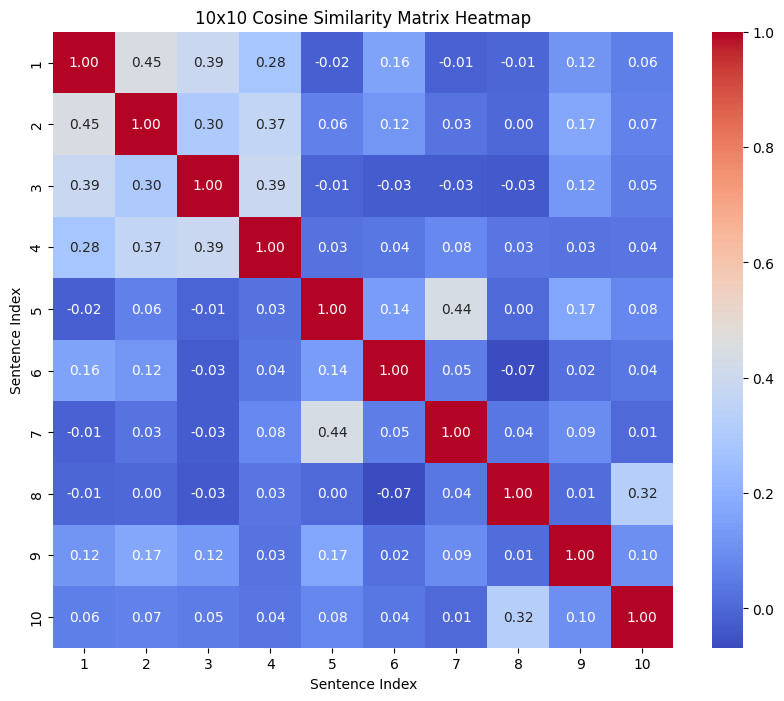

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=range(1,11), yticklabels=range(1,11))

plt.title("10x10 Cosine Similarity Matrix Heatmap")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

# Compute similarity with all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

In [7]:
import numpy as np

top_indices = np.argsort(query_similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler took a hat-trick in the game
Similarity Score: 0.6441

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

